In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/home/lolkek3310/python/Подготовка Гомель/Кластеризация/Uber Pickups in New York City/uber-raw-data-apr14.csv',nrows=100000)

coords = np.radians(df[['Lat','Lon']])

kms_per_radian = 6371.0088

epsilon = 0.2 / kms_per_radian

db = DBSCAN(eps=epsilon,
            algorithm= 'ball_tree',
            min_samples= 20,
            metric='haversine'       
            ).fit(coords)
df['Cluster'] = db.labels_
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = list(db.labels_).count(-1)
print(f"Найдено кластеров: {n_clusters}")
print(f"Точек-аномалий (шум): {n_noise} ({(n_noise/len(df))*100:.2f}%)")

Найдено кластеров: 43
Точек-аномалий (шум): 5969 (5.97%)


In [18]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=50,
                            metric='haversine',
                            prediction_data=True)

df['Cluster_HDBSCAN'] = clusterer.fit_predict(coords)

df['Anomaly_Score'] = clusterer.outlier_scores_

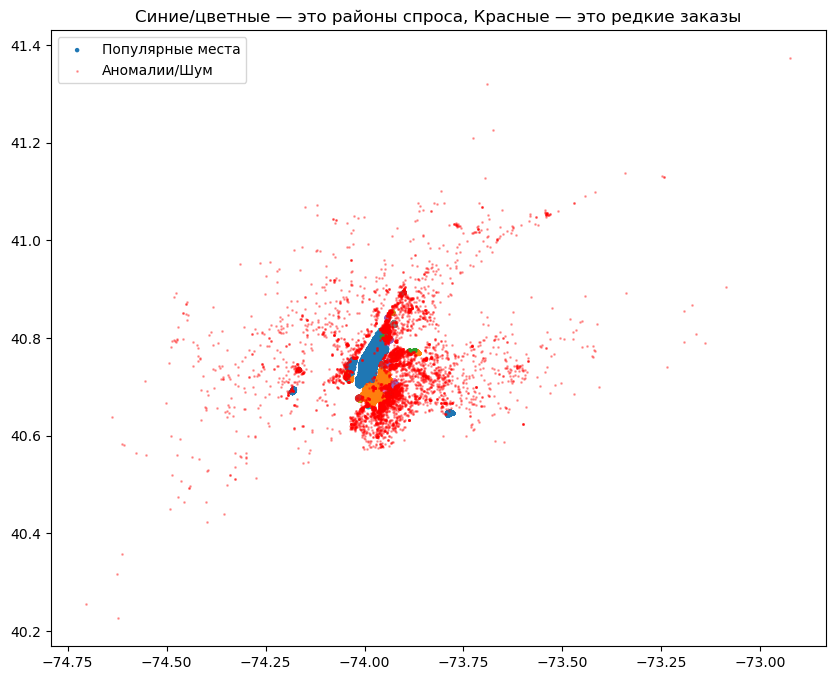

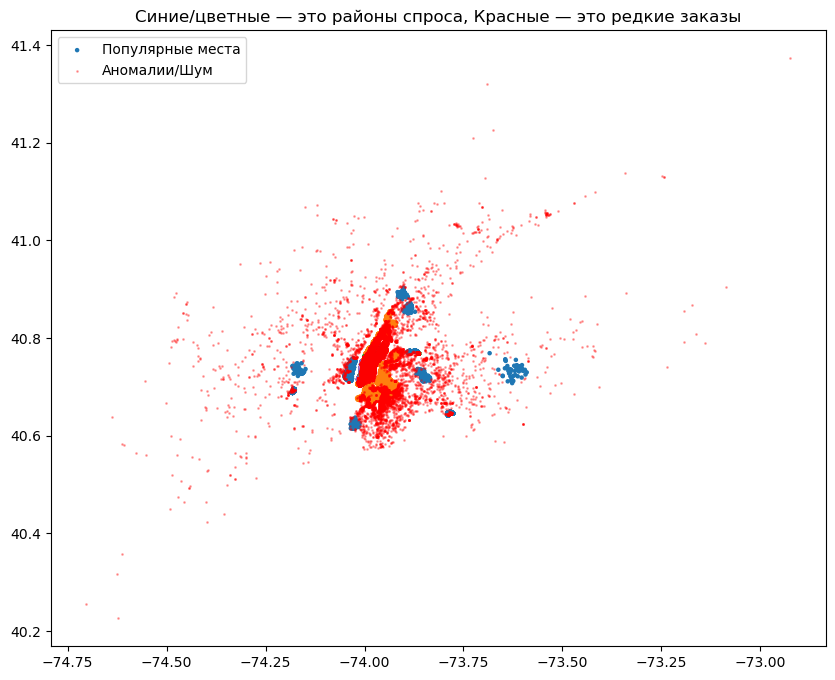

In [19]:
plt.figure(figsize=(10, 8))

# Рисуем обычные точки (кластеры) — они будут цветными
# Те точки, что получили Cluster >= 0
clustered = df[df['Cluster'] != -1]
plt.scatter(clustered['Lon'], clustered['Lat'], c=clustered['Cluster'], cmap='tab10', s=5, label='Популярные места')

# Рисуем аномалии (шум) — они будут красными
# Те точки, что получили Cluster == -1
anomalies = df[df['Cluster'] == -1]
plt.scatter(anomalies['Lon'], anomalies['Lat'], c='red', s=1, alpha=0.3, label='Аномалии/Шум')

plt.title('Синие/цветные — это районы спроса, Красные — это редкие заказы')
plt.legend()
plt.show()
plt.figure(figsize=(10, 8))

# Рисуем обычные точки (кластеры) — они будут цветными
# Те точки, что получили Cluster >= 0
clustered = df[df['Cluster_HDBSCAN'] != -1]
plt.scatter(clustered['Lon'], clustered['Lat'], c=clustered['Cluster_HDBSCAN'], cmap='tab10', s=5, label='Популярные места')

# Рисуем аномалии (шум) — они будут красными
# Те точки, что получили Cluster == -1
anomalies = df[df['Cluster_HDBSCAN'] == -1]
plt.scatter(anomalies['Lon'], anomalies['Lat'], c='red', s=1, alpha=0.3, label='Аномалии/Шум')

plt.title('Синие/цветные — это районы спроса, Красные — это редкие заказы')
plt.legend()
plt.show()

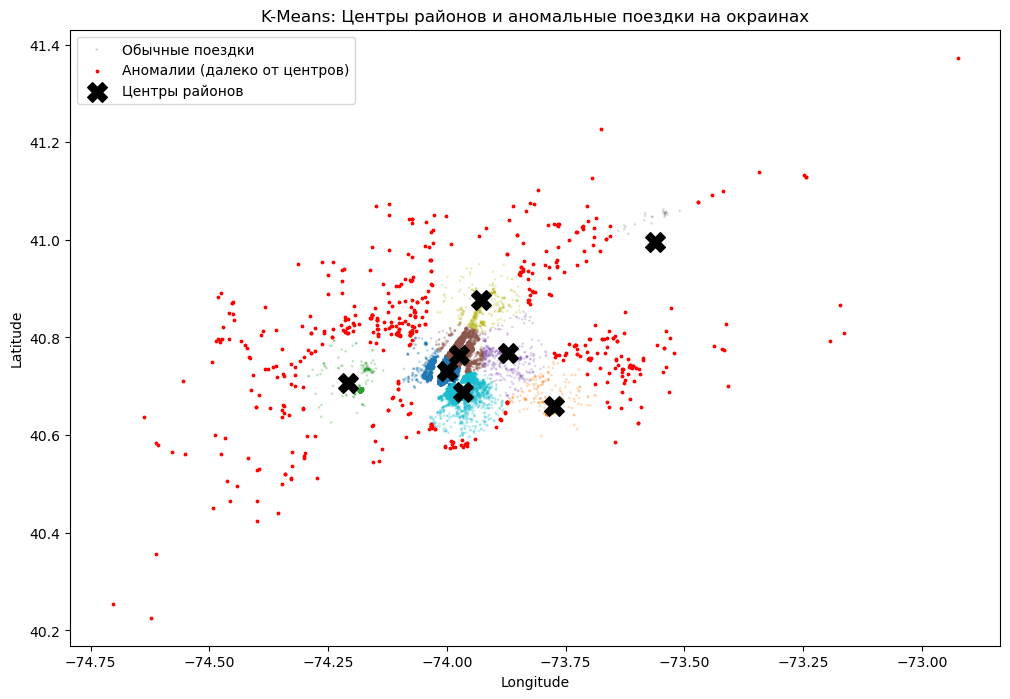

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Загрузка данных
df = pd.read_csv('/home/lolkek3310/python/Подготовка Гомель/Кластеризация/Uber Pickups in New York City/uber-raw-data-apr14.csv', nrows=50000)
coords = df[['Lat', 'Lon']]

# 2. Обучаем K-Means
# Допустим, мы хотим разделить Нью-Йорк на 8 главных районов (баз)
kmeans = KMeans(n_clusters=8, random_state=42)
df['Cluster'] = kmeans.fit_predict(coords)

# 3. ПОИСК АНОМАЛИЙ
# В K-Means аномалия — это точка, которая очень далеко от центра (центроида) своего кластера
centers = kmeans.cluster_centers_ # Координаты центров

# Функция для расчета расстояния каждой точки до центра её кластера
def get_distance(row):
    center = centers[int(row['Cluster'])]
    # Обычное расстояние (Евклидово)
    return np.sqrt((row['Lat'] - center[0])**2 + (row['Lon'] - center[1])**2)

df['Distance'] = df.apply(get_distance, axis=1)

# Выбираем порог аномальности (например, 5% самых удаленных точек)
threshold = df['Distance'].quantile(0.99)
df['Is_Anomaly'] = df['Distance'] > threshold

# 4. ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(12, 8))

# Рисуем обычные точки (прозрачные, чтобы не забивали экран)
normal = df[df['Is_Anomaly'] == False]
plt.scatter(normal['Lon'], normal['Lat'], c=normal['Cluster'], cmap='tab10', s=1, alpha=0.2, label='Обычные поездки')

# Рисуем аномалии (яркие точки)
anomalies = df[df['Is_Anomaly'] == True]
plt.scatter(anomalies['Lon'], anomalies['Lat'], c='red', s=3, label='Аномалии (далеко от центров)')

# Рисуем центры кластеров (большие кресты)
plt.scatter(centers[:, 1], centers[:, 0], c='black', marker='X', s=200, label='Центры районов')

plt.title('K-Means: Центры районов и аномальные поездки на окраинах')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()